#Data set


In [ ]:
!pip install torchcodec
!pip install datasets
!pip install sounddevice
!pip install tokenizers
!apt-get install -y portaudio19-dev
!pip install pyaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
Suggested packages:
  libasound2-doc jackd1 portaudio19-doc
The following packages will be REMOVED:
  libjack-jackd2-0
The following NEW packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
  portaudio19-dev
0 upgraded, 6 newly installed, 1 to remove and 41 not upgraded.
Need to get 596 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack0 amd64 1:0.125.0-3build2 [93.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libasound2-dev amd64 1.2.6.1-1ubuntu1 [110 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack-dev amd64 1:

In [ ]:
import torchcodec # Explicitly import torchcodec
import datasets
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tokenizers import Tokenizer, pre_tokenizers, decoders, models, trainers
from tokenizers.processors import TemplateProcessing
from pathlib import Path
import sounddevice as sa

dataset = datasets.load_dataset(
    "m-aliabbas/idrak_timit_subsample1",
    split="train",
)

data = next(iter(dataset))
audio = data['audio']['array']
sample_rate = data['audio']['sampling_rate']
transcript = data['transcription']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-aeb35d2d506d38(…):   0%|          | 0.00/29.5M [00:00<?, ?B/s]

data/test-00000-of-00001-0dca1a897ce597d(…):   0%|          | 0.00/1.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1296 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/324 [00:00<?, ? examples/s]

In [ ]:
print(audio.shape)
print(sample_rate)
print('Audio length(s):', audio.size / sample_rate)
print(transcript)

(35840,)
16000
Audio length(s): 2.24
don t ask me to carry an oily rag like that


In [ ]:
from IPython.display import Audio
Audio(audio, rate=sample_rate)

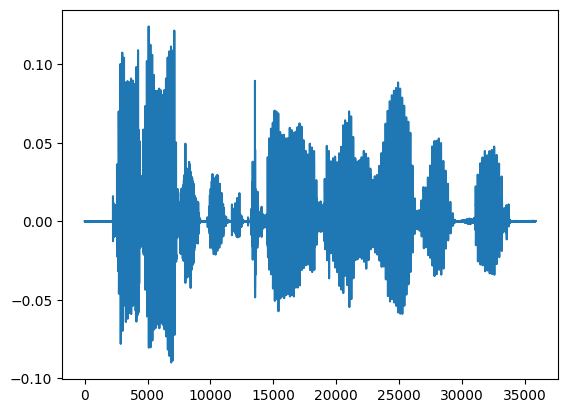

In [ ]:
import matplotlib.pyplot as plt

plt.plot(audio)
plt.show()

In [ ]:
def collate_fn(batch):
  # Ensure all 'audio' items in the batch are torch.Tensors
  # If an AudioDecoder object somehow made it here, process it.
  processed_batch = []
  for item_data in batch:
    current_audio = item_data['audio']
    if not isinstance(current_audio, torch.Tensor):
      # Assume it's an AudioDecoder object if not a tensor, and try to extract the array
      if hasattr(current_audio, 'array'):
        item_data['audio'] = torch.from_numpy(current_audio.array).float()
      else:
        # If it's neither a tensor nor an AudioDecoder with an 'array' attribute, something is very wrong.
        raise TypeError(f"Unexpected audio type encountered in collate_fn: {type(current_audio)}")
    processed_batch.append(item_data)

  max_audio_len = max([data['audio'].shape[0] for data in processed_batch])

  max_ids_len = 0
  has_input_ids = "input_ids" in processed_batch[0]
  if has_input_ids:
    max_ids_len = max([len(data["input_ids"]) for data in processed_batch])

  audio_tensor = torch.stack(
      [
          F.pad(data["audio"], (0, max_audio_len - data["audio"].shape[0]))
          for data in processed_batch
      ]
  )
  # Add a channel dimension: (batch_size, 1, seq_len)
  audio_tensor = audio_tensor.unsqueeze(1)

  output_dict = {
      "audio": audio_tensor,
      "text": [data["text"]for data in processed_batch],
  }

  if has_input_ids:
    input_ids_tensor = torch.stack(
        [
            F.pad(
                torch.tensor(data["input_ids"]),
                (0, max_ids_len - len(data["input_ids"])),
                value = 0,
            )
            for data in processed_batch
        ]
    )
    output_dict["input_ids"] = input_ids_tensor

  return output_dict

In [ ]:
from tokenizers import Tokenizer, pre_tokenizers, decoders, models

def get_tokenizer(save_path = 'tokenizer.json'):
  tokenizer = Tokenizer(models.BPE())
  tokenizer.add_special_tokens(["$"])
  tokenizer.add_tokens(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ '"))

  tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()
  tokenizer.decoder = decoders.ByteLevel()
  tokenizer.blank_token = tokenizer.token_to_id('$')
  tokenizer.save(save_path)
  return tokenizer

In [ ]:
class CommanVoiceDataset(Dataset):
  def __init__(self, comman_voice_dataset, num_example, tokenizer):
    self.dataset = comman_voice_dataset
    self.num_example = (
        min(num_example, len(self.dataset))
        if num_example is not None
        else len(self.dataset)
    )
    self.tokenizer = tokenizer

  def __len__(self):
    return self.num_example

  def __getitem__(self, ids):
    item = self.dataset[ids]
    waveform = torch.from_numpy(item['audio']['array']).float()
    text = item['transcription'].upper()
    if self.tokenizer:
      encoded = self.tokenizer.encode(text)
      return {'audio': waveform, 'text':text, "input_ids": encoded.ids}

    return {'audio': waveform, 'text':text}

In [ ]:
tokenizer = get_tokenizer()
sorted(tokenizer.get_vocab().items(), key=lambda x: x[1])

[('$', 0),
 ('A', 1),
 ('B', 2),
 ('C', 3),
 ('D', 4),
 ('E', 5),
 ('F', 6),
 ('G', 7),
 ('H', 8),
 ('I', 9),
 ('J', 10),
 ('K', 11),
 ('L', 12),
 ('M', 13),
 ('N', 14),
 ('O', 15),
 ('P', 16),
 ('Q', 17),
 ('R', 18),
 ('S', 19),
 ('T', 20),
 ('U', 21),
 ('V', 22),
 ('W', 23),
 ('X', 24),
 ('Y', 25),
 ('Z', 26),
 (' ', 27),
 ("'", 28)]

In [ ]:
transcript = "avb's"
transcript = transcript.upper()
input_ids = tokenizer.encode(transcript).ids
print(input_ids)

[1, 22, 2, 28, 19]


In [ ]:
def get_dataset(
    batch_size = 32,
    num_example = None,
    num_workers = 4,
):
  dataset = datasets.load_dataset(
    "m-aliabbas/idrak_timit_subsample1",
    split="train",
  )
  tokenizer = get_tokenizer()
  dataset = CommanVoiceDataset(dataset, tokenizer=tokenizer, num_example=num_example)
  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=True,
      collate_fn=collate_fn,
      num_workers=num_workers,
  )
  return dataloader

In [ ]:
if __name__ == "__main__":
  dataloader = get_dataset(batch_size=32)
  for batch in dataloader:
    audio = batch["audio"]
    input_ids = batch["input_ids"]
    print(audio.shape)
    print(input_ids.shape)
    break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([32, 1, 82637])
torch.Size([32, 78])


#Convolitional Model

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
class ResidualDownSampleBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride, kernel_size=4):
    super().__init__()
    self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size= kernel_size, padding="same")
    self.bn1 = nn.BatchNorm1d(out_channels)
    self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size= kernel_size, stride= stride)
    self.relu = nn.ReLU()

  def forward(self, x):
    output = self.conv1(x)
    output = self.bn1(output)
    output = self.relu(output) + x # Residual connection: add input x to the output after activation
    output = self.conv2(output)
    return output

In [ ]:
class DownssamplingNetwork(nn.Module):
  def __init__(self, embedding_dim=128, hidden_dim=64, in_channels=1, inital_mean_pooling_kernek_size=2, stride=[6,6,8,4,2]):
    super().__init__()
    self.layer = nn.ModuleList()
    self.mean_pooling = nn.AvgPool1d(kernel_size=inital_mean_pooling_kernek_size, stride=inital_mean_pooling_kernek_size)

    for i in range(len(stride)):
      self.layer.append(ResidualDownSampleBlock(hidden_dim if i > 0 else in_channels, hidden_dim, stride[i], kernel_size=8))

    self.final_conv = nn.Conv1d(hidden_dim, embedding_dim, kernel_size=4, padding="same")

  def forward(self, x):
    x = self.mean_pooling(x)
    for layer in self.layer:
      x = layer(x)

    x = self.final_conv(x)
    x = x.transpose(1,2)
    return x

In [ ]:
if __name__ == "__main__":

  batch_size = 2
  input_embedding_dim = 1
  seq_len = 237680

  output_embedding_dim = 32
  strides = [2, 4, 8]
  initial_mean_pooling_kernel_size = 2

  model = DownssamplingNetwork(embedding_dim=output_embedding_dim, stride=strides, in_channels=input_embedding_dim, inital_mean_pooling_kernek_size=initial_mean_pooling_kernel_size)
  x = torch.randn(batch_size, 1, seq_len)
  print(model(x).shape)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv1d(


torch.Size([2, 1856, 32])


#self Attention


In [ ]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F

In [ ]:
def calculate_statement(values: torch.Tensor, query: torch.Tensor, keys: torch.Tensor):
  attention_scores = torch.matmul(query, keys.transpose(-2, -1))
  attention_scores /= math.sqrt(keys.shape[-1])
  attention_scores = F.softmax(attention_scores, dim=-1)
  attention = torch.matmul(attention_scores, values)
  return attention, attention_scores

In [ ]:
class FeedForword(nn.Module):
  def __init__(self, embed_size: int):
    super().__init__()
    self.layer1 = nn.Linear(embed_size, embed_size * 4) # Corrected input to expand dimension
    self.layer2 = nn.Linear(embed_size * 4, embed_size)

  def forward(self, x):
    x = self.layer1(x)
    x = F.gelu(x)
    x = self.layer2(x)
    return x

In [ ]:
class SelfAttentionLayer(nn.Module):
  def __init__(self, embed_size: int):
    super().__init__()
    self.embed_size = embed_size
    self.query_dense = nn.Linear(embed_size, embed_size)
    self.key_dense = nn.Linear(embed_size, embed_size)
    self.value_dense = nn.Linear(embed_size, embed_size)

  def forward(self, embeddings: torch.Tensor):
    query = self.query_dense(embeddings)
    key = self.key_dense(embeddings)
    value = self.value_dense(embeddings)
    attention, _ = calculate_statement(value, query, key)
    return attention

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_size: int, num_heads: int):
    super().__init__()
    assert (
        embed_size % num_heads == 0
    ), "Embedding size must be divisible by number of heads"

    self.embed_size = embed_size
    self.num_heads = num_heads
    self.head_dim = embed_size // num_heads

    self.query = nn.Linear(embed_size, embed_size)
    self.key = nn.Linear(embed_size, embed_size)
    self.value = nn.Linear(embed_size, embed_size)
    self.fc = nn.Linear(embed_size, embed_size)

  def forward(self, embeddings: torch.Tensor):
    batch_size, seq_len, _ = embeddings.shape

    queries = self.query(embeddings).view(batch_size, seq_len, self.num_heads, self.head_dim)
    keys = self.key(embeddings).view(batch_size, seq_len, self.num_heads, self.head_dim)
    values = self.value(embeddings).view(batch_size, seq_len, self.num_heads, self.head_dim)

    queries = queries.transpose(1, 2)  # (batch_size, num_heads, seq_len, head_dim)
    keys = keys.transpose(1, 2)      # (batch_size, num_heads, seq_len, head_dim)
    values = values.transpose(1, 2)    # (batch_size, num_heads, seq_len, head_dim)

    attention, _ = calculate_statement(values, queries, keys)

    attention = attention.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_size)

    output = self.fc(attention)
    return output

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, embed_size: int, num_heads: int):
    super().__init__()
    self.attention = MultiHeadAttention(embed_size, num_heads)
    self.feed_forward = FeedForword(embed_size)
    self.layer_norm1 = nn.LayerNorm(embed_size)

  def forward(self, embeddings: torch.Tensor):
    context = self.attention(embeddings)
    context = self.layer_norm1(context)
    context = self.feed_forward(context)
    context = F.relu(context)
    output = context + embeddings
    return output

In [ ]:
class SinusoidalPositionalEmbedding(nn.Module):
  def __init__(self, embedding_dim: int, max_len: int):
    super().__init__()
    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, embedding_dim, 2) * -(math.log(10000.0) / embedding_dim))
    pe = torch.zeros(max_len, embedding_dim)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer("positional_embedding",pe)

  def forward(self, x: torch.Tensor):
    return x + self.positional_embedding[:x.size(1), :]

In [ ]:
class Transformer(nn.Module):
  def __init__(self, embedding_size: int, num_layers: int, num_heads: int, max_seq_len: int):
    super().__init__()
    self.positional_encoding = SinusoidalPositionalEmbedding(embedding_size, max_seq_len)
    self.transformer_blocks = nn.ModuleList([TransformerBlock(embedding_size, num_heads) for _ in range(num_layers)])

  def forward(self, x: torch.Tensor):
    x = self.positional_encoding(x)
    for transformer_block in self.transformer_blocks:
      x = transformer_block(x)
    return x

In [ ]:
if __name__ == "__main__":
  transformer = Transformer(embedding_size=128, num_layers=3, num_heads=8, max_seq_len=15) # Added num_heads=8
  x = torch.randn(2, 10, 128)
  print(transformer(x).shape)

torch.Size([2, 10, 128])


# Optimizing RYQ (Residual Vector Quantizer)

In [ ]:
import torch
import torch.nn as nn

In [ ]:
from torch.nn.modules import distance
class VectorQuantizer(nn.Module):
  def __init__(self, num_embeddings, embedding_dim, commitment_cost = 0.25):
    super().__init__()
    self.num_embeddings = num_embeddings
    self.embedding_dim = embedding_dim

    self.embedding = nn.Embedding(num_embeddings, embedding_dim)
    nn.init.uniform_(self.embedding.weight, -0.1, 0.1)

    self.commitment_cost = commitment_cost # Corrected typo here

  def forward(self, x):
    # shape: (B, T, D)
    batch_size, sequence_length, embedding_dim = x.shape

    flat_x = x.reshape(batch_size*sequence_length, embedding_dim) # (B*T, D)

    # coompute diatences (B*T, N)
    distance = torch.cdist(
        flat_x, self.embedding.weight, p=2
    )

    encoding_indices = torch.argmin(distance, dim=1)
    quantized = self.embedding(encoding_indices).view(
        batch_size, sequence_length, embedding_dim
    )

    # Modified loss computation with scaling
    e_latent_loss = torch.mean((quantized.detach() - x)**2)
    q_latent_loss = torch.mean((quantized - x.detach())**2)

    loss = q_latent_loss + self.commitment_cost * e_latent_loss

    quantized = x + (quantized - x).detach()

    return quantized, loss

In [ ]:
class ResidualVectorQuantizer(nn.Module):
  def __init__(self, num_codebooks, codebook_size, embedding_dim):
    super().__init__()
    self.codebooks = nn.ModuleList([
        VectorQuantizer(codebook_size, embedding_dim)
        for _ in range(num_codebooks)
    ])

  def forward(self, x):
    out = 0
    total_loss = 0
    for codebook in self.codebooks:
      quantized, loss = codebook(x)
      out += quantized
      total_loss += loss
    return out, total_loss

In [ ]:
if __name__ == "__main__":
  rvq = ResidualVectorQuantizer(num_codebooks=2, codebook_size=16, embedding_dim=128)
  x = torch.randn(2, 10, 128, requires_grad=True)
  optimizer = torch.optim.Adam(rvq.parameters(), lr=0.001)
  for i in range(4):
    output, loss = rvq(x)

    recon_loss = torch.mean((output -x)**2)
    total_loss = recon_loss + loss
    total_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    print(f"loss: {total_loss.item()}, recon_loss: {recon_loss.item()}, loss: {loss.item()}")

loss: 3.489187240600586, recon_loss: 0.986210823059082, loss: 2.502976417541504
loss: 3.484208583831787, recon_loss: 0.984012246131897, loss: 2.5001962184906006
loss: 3.479240655899048, recon_loss: 0.9818194508552551, loss: 2.4974212646484375
loss: 3.4742836952209473, recon_loss: 0.9796324968338013, loss: 2.4946513175964355


# Puting it all together

In [ ]:
import torch.nn as nn
import torch

In [ ]:
class TranscribeModel(nn.Module):
  def __init__(self,
      num_codebooks: int,
      codebook_size: int,
      embedding_dim: int,
      vocab_size: int,
      stridrs: list,
      num_layers: int,
      initial_mean_pooling_kernel_size: int,
      num_heads: int,
      max_seq_len: int = 2000,
  ):
    super().__init__()
    self.options = {
        'num_codebooks': num_codebooks,
        'codebook_size': codebook_size,
        'embedding_dim': embedding_dim,
        'vocab_size': vocab_size,
        'stridrs': stridrs,
        'num_layers': num_layers,
        'initial_mean_pooling_kernel_size': initial_mean_pooling_kernel_size,
        'num_heads': num_heads,
        'max_seq_len': max_seq_len,
    }
    self.downsampling = DownssamplingNetwork(
        embedding_dim=embedding_dim,
        stride=stridrs,
        in_channels=1,
        hidden_dim= embedding_dim // 2,
        inital_mean_pooling_kernek_size=initial_mean_pooling_kernel_size,
    )
    self.transformer = Transformer(
        embedding_size=embedding_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        max_seq_len=max_seq_len,
    )
    self.rvq = ResidualVectorQuantizer(
        num_codebooks=num_codebooks,
        codebook_size=codebook_size,
        embedding_dim=embedding_dim,
    )
    self.output_layer = nn.Linear(embedding_dim, vocab_size)

  def forward(self, x):
    x = self.downsampling(x)
    x = self.transformer(x)
    x, loss = self.rvq(x)
    x = self.output_layer(x)
    x = torch.log_softmax(x, dim=-1)
    return x, loss

  def save(self, path: str):
    print("saving model to ", path)
    torch.save({"model": self.state_dict(), "options": self.options}, path)

  @staticmethod
  def load(path: str):
    print("Loasding model from ", path)
    model = TranscribeModel(**torch.load(path)["options"])
    model.load_state_dict(torch.load(path)["model"])
    return model

In [ ]:
if __name__ == "__main__":
  model = TranscribeModel(
      num_codebooks=3,
      codebook_size=64,
      embedding_dim=64,
      vocab_size=100,
      stridrs=[6, 8, 4, 2],
      initial_mean_pooling_kernel_size=4,
      max_seq_len=2000,
      num_layers=2,
      num_heads=8 # Added missing num_heads argument
  )
  x = torch.randn(4, 1, 23768) # Corrected input tensor shape to include channel dimension
  model_output, aux_loss = model(x) # Assign model output to two variables
  print(model_output.shape) # Print shape of the actual output tensor

torch.Size([4, 11, 100])


# Trainning

In [ ]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "talse"
os.environ["pYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from torch.utils.tensorboard import SummaryWriter

import torch

torch.autograd.set_detect_anomaly(True)

from torch import nn

In [ ]:
vq_initial_loss_weight = 10
vq_warmup_steps = 1000
vq_final_loss_weight = 0.5
num_epoch = 10
starting_steps = 0
num_example = 16000
model_id = "test37"
num_batch_repeats = 1

starting_steps = 0
BATCH_SIZE = 64
LEARNING_RATE = 0.005

def run_loss_function(log_probs, target, blank_token, input_lengths, target_lengths):
  loss_function = nn.CTCLoss(blank = blank_token)
  input_seq_first = log_probs.permute(1, 0, 2)
  loss = loss_function(input_seq_first, target, input_lengths, target_lengths)
  return loss

In [ ]:
print(f"vq_initial_loss_weight: {vq_initial_loss_weight}")
print(f"vq_warmup_steps: {vq_warmup_steps}")
print(f"vq_final_loss_weight: {vq_final_loss_weight}")
print(f"num_epoch: {num_epoch}")
print(f"starting_steps: {starting_steps}")
print(f"num_example: {num_example}")
print(f"model_id: {model_id}")
print(f"num_batch_repeats: {num_batch_repeats}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"LEARNING_RATE: {LEARNING_RATE}")

vq_initial_loss_weight: 10
vq_warmup_steps: 1000
vq_final_loss_weight: 0.5
num_epoch: 10
starting_steps: 0
num_example: 16000
model_id: test37
num_batch_repeats: 1
BATCH_SIZE: 64
LEARNING_RATE: 0.005


In [ ]:
import os
import shutil
from torch.utils.tensorboard import SummaryWriter
import torch

# Ensure environment variables are set
os.environ["TOKENIZERS_PARALLELISM"] = "true" # Corrected typo 'talse' to 'true'
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# 1. Set up the logging directory using SummaryWriter
log_dir = f"/home/{model_id}"
if os.path.exists(log_dir):
    shutil.rmtree(log_dir)
write = SummaryWriter(log_dir=log_dir)

# 2. Get the tokenizer
tokenizer = get_tokenizer()

# 3. Determine the blank token ID
blank_token = tokenizer.token_to_id("$")

# 4. Set the device for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 5. Check if a saved model exists or instantiate a new one
model_path = f"/home/{model_id}/model.pt"
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model = TranscribeModel.load(model_path).to(device)
else:
    print("Instantiating new model.")
    model = TranscribeModel(
        num_codebooks=3,
        codebook_size=64,
        embedding_dim=64,
        vocab_size=len(tokenizer.get_vocab()),
        stridrs=[6, 8, 4, 2],
        initial_mean_pooling_kernel_size=4,
        max_seq_len=2000,
        num_layers=2,
        num_heads=8,
    ).to(device)

# 6. Print the total number of trainable parameters
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_trainable_params}")


Using device: cuda
Instantiating new model.
Number of trainable parameters: 180253


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

dataloader = get_dataset(
    batch_size=BATCH_SIZE,
    num_example=num_example,
    num_workers=1 # Set num_workers to 1 to avoid issues in Colab when running in a multi-process environment
)

print("Optimizer and DataLoader initialized.")

Optimizer and DataLoader initialized.


In [ ]:
def collate_fn(batch):
  processed_batch = []
  for item_data in batch:
    current_audio = item_data['audio']
    if not isinstance(current_audio, torch.Tensor):
      if hasattr(current_audio, 'array'):
        item_data['audio'] = torch.from_numpy(current_audio.array).float()
      else:
        raise TypeError(f"Unexpected audio type encountered in collate_fn: {type(current_audio)}")
    processed_batch.append(item_data)

  max_audio_len = max([data['audio'].shape[0] for data in processed_batch])

  max_ids_len = 0
  has_input_ids = "input_ids" in processed_batch[0]
  if has_input_ids:
    max_ids_len = max([len(data["input_ids"]) for data in processed_batch])

  audio_tensor = torch.stack(
      [
          F.pad(data["audio"], (0, max_audio_len - data["audio"].shape[0]))
          for data in processed_batch
      ]
  )
  # Add a channel dimension to the audio_tensor (batch_size, 1, sequence_length)
  audio_tensor = audio_tensor.unsqueeze(1)

  output_dict = {
      "audio": audio_tensor,
      "text": [data["text"] for data in processed_batch],
  }

  if has_input_ids:
    input_ids_tensor = torch.stack(
        [
            F.pad(
                torch.tensor(data["input_ids"]),
                (0, max_ids_len - len(data["input_ids"])),
                value=0,
            )
            for data in processed_batch
        ]
    )
    output_dict["input_ids"] = input_ids_tensor

  return output_dict

In [ ]:
steps = starting_steps # Initialize steps at the beginning of the training loop

# Initialize lists to store epoch-level losses
epoch_ctc_losses = []
epoch_vq_losses = []
epoch_total_losses = []

for i in range(num_epoch):
  # Initialize accumulators for the current epoch
  current_epoch_ctc_sum = 0.0
  current_epoch_vq_sum = 0.0
  current_epoch_total_sum = 0.0
  epoch_batch_count = 0

  # Initialize per-step loss lists for the current epoch (for 20-step logging)
  ctc_losses_list = []
  vq_losses_list = []

  for idx, batch in enumerate(dataloader):
    for repeat_batch in range(num_batch_repeats):
      audio = batch['audio']
      target = batch['input_ids']
      text = batch['text']

      if not isinstance(audio, torch.Tensor):
          raise TypeError("Audio in batch was not a torch.Tensor, check collate_fn")

      # Move audio and target to device before model forward pass
      audio = audio.to(device)
      target = target.to(device)

      optimizer.zero_grad()
      model_output, aux_loss = model(audio)

      # Check if the model output sequence is shorter than the target sequence for CTC
      input_lengths_for_ctc = torch.tensor([model_output.shape[1]] * model_output.shape[0], dtype=torch.long, device=device)
      target_lengths_for_ctc = (target != blank_token).sum(1)

      # Filter out samples where input_length is less than target_length
      valid_indices = input_lengths_for_ctc >= target_lengths_for_ctc

      if not valid_indices.all():
          # print(f"Skipping {valid_indices.shape[0] - valid_indices.sum()} samples where input_length < target_length for CTC.")
          model_output_filtered = model_output[valid_indices]
          target_filtered = target[valid_indices]
          input_lengths_for_ctc_filtered = input_lengths_for_ctc[valid_indices]
          target_lengths_for_ctc_filtered = target_lengths_for_ctc[valid_indices]

          if model_output_filtered.shape[0] == 0:
              print("No valid samples in batch after filtering, skipping step.")
              continue

          ctc_loss = run_loss_function(
              model_output_filtered,
              target_filtered,
              blank_token,
              input_lengths_for_ctc_filtered,
              target_lengths_for_ctc_filtered
          )
      else:
          ctc_loss = run_loss_function(
              model_output,
              target,
              blank_token,
              input_lengths_for_ctc,
              target_lengths_for_ctc
          )

      vq_losses_weight = max(
          vq_final_loss_weight,
          vq_initial_loss_weight - (vq_initial_loss_weight - vq_final_loss_weight) * (steps / vq_warmup_steps),
      )

      loss = ctc_loss + vq_losses_weight * aux_loss

      if torch.isinf(loss) or torch.isnan(loss):
        print("Loss is inf or nan, skipping step.")
        continue

      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
      optimizer.step()
      optimizer.zero_grad() # Clear gradients after step()

      # Accumulate losses for epoch-level averaging
      current_epoch_ctc_sum += ctc_loss.item()
      current_epoch_vq_sum += aux_loss.item()
      current_epoch_total_sum += loss.item()
      epoch_batch_count += 1

      ctc_losses_list.append(ctc_loss.item()) # Accumulate for 20-step logging
      vq_losses_list.append(aux_loss.item()) # Accumulate for 20-step logging
      steps += 1

      if steps % 20 == 0:
        # Ensure lists are not empty before calculating average
        if len(ctc_losses_list) > 0:
            avg_ctc_loss = sum(ctc_losses_list) / len(ctc_losses_list)
            avg_vq_loss = sum(vq_losses_list) / len(vq_losses_list)
            total_avg_loss = avg_ctc_loss + vq_losses_weight * avg_vq_loss # This is the running average for the last 20 steps
            write.add_scalar("loss/ctc", avg_ctc_loss, steps)
            write.add_scalar("loss/vq", avg_vq_loss, steps)
            write.add_scalar("loss/total", total_avg_loss, steps)
            print(f"Epoch: {i}, Step: {steps}, CTC Loss: {avg_ctc_loss:.4f}, VQ Loss: {avg_vq_loss:.4f}, Total Loss: {total_avg_loss:.4f}")

            # Clear lists after logging to average over the next 20 steps
            ctc_losses_list = []
            vq_losses_list = []

  # After all batches in an epoch, calculate and store epoch-level averages
  if epoch_batch_count > 0:
      epoch_ctc_losses.append(current_epoch_ctc_sum / epoch_batch_count)
      epoch_vq_losses.append(current_epoch_vq_sum / epoch_batch_count)
      epoch_total_losses.append(current_epoch_total_sum / epoch_batch_count)

      # Log epoch-wise losses to TensorBoard
      write.add_scalar("epoch_loss/ctc", epoch_ctc_losses[-1], i)
      write.add_scalar("epoch_loss/vq", epoch_vq_losses[-1], i)
      write.add_scalar("epoch_loss/total", epoch_total_losses[-1], i)
      print(f"Epoch {i+1} Summary: Avg CTC Loss = {epoch_ctc_losses[-1]:.4f}, Avg VQ Loss = {epoch_vq_losses[-1]:.4f}, Total Avg Loss = {epoch_total_losses[-1]:.4f}")

  # Save model after each epoch
  model.save(f"/home/{model_id}/model_epoch_.pt")

# Final save after all epochs
model.save(f"/home/{model_id}/model.pt")

print("Training complete.")
write.close()

Epoch: 0, Step: 20, CTC Loss: 3.4747, VQ Loss: 1.5647, Total Loss: 18.8397
Epoch 1 Summary: Avg CTC Loss = 3.4583, Avg VQ Loss = 1.5301, Total Avg Loss = 18.6435
saving model to  /home/test37/model_epoch_.pt
Epoch: 1, Step: 40, CTC Loss: 2.9284, VQ Loss: 0.7585, Total Loss: 10.2321
Epoch 2 Summary: Avg CTC Loss = 2.9086, Avg VQ Loss = 0.7917, Total Avg Loss = 10.5878
saving model to  /home/test37/model_epoch_.pt
Epoch: 2, Step: 60, CTC Loss: 2.4889, VQ Loss: 1.4689, Total Loss: 16.3546
Epoch 3 Summary: Avg CTC Loss = 2.4659, Avg VQ Loss = 1.6032, Total Avg Loss = 17.6834
saving model to  /home/test37/model_epoch_.pt
Epoch: 3, Step: 80, CTC Loss: 1.8444, VQ Loss: 1.7684, Total Loss: 18.2008
Epoch 4 Summary: Avg CTC Loss = 1.7959, Avg VQ Loss = 1.6243, Total Avg Loss = 16.9343
saving model to  /home/test37/model_epoch_.pt
Epoch: 4, Step: 100, CTC Loss: 1.4789, VQ Loss: 0.9214, Total Loss: 9.8263
Epoch 5 Summary: Avg CTC Loss = 1.4363, Avg VQ Loss = 0.8715, Total Avg Loss = 9.3813
saving 

## Plotting Epoch Losses

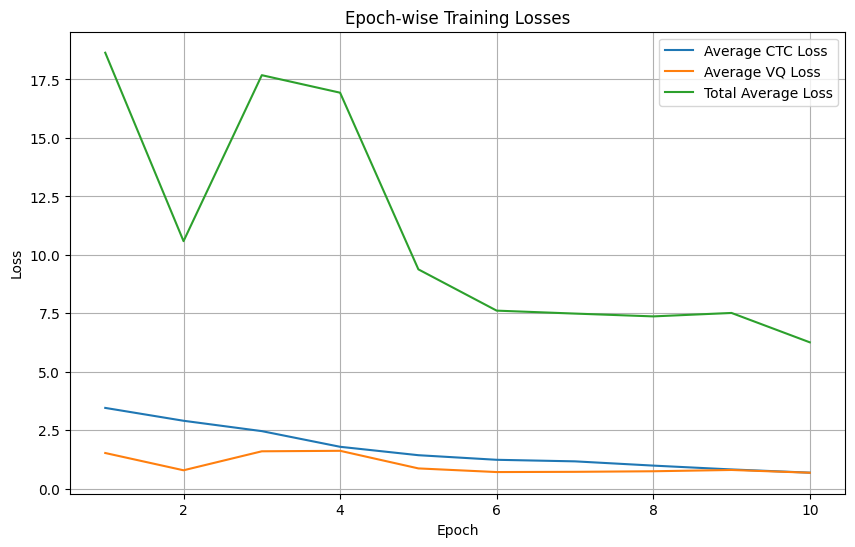

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epoch + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, epoch_ctc_losses, label='Average CTC Loss')
plt.plot(epochs, epoch_vq_losses, label='Average VQ Loss')
plt.plot(epochs, epoch_total_losses, label='Total Average Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch-wise Training Losses')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_id = 'test37'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = get_tokenizer() # The get_tokenizer function creates and saves the tokenizer if it doesn't exist.
print("Tokenizer loaded.")

model_path = f"/home/{model_id}/model.pt"
model = TranscribeModel.load(model_path).to(device)
print(f"Model loaded from {model_path} and moved to {device}.")

Using device: cuda
Tokenizer loaded.
Loasding model from  /home/test37/model.pt
Model loaded from /home/test37/model.pt and moved to cuda.


In [ ]:
dataset = datasets.load_dataset(
    "m-aliabbas/idrak_timit_subsample1",
    split="train",
)

# Select a random sample from the dataset
sample_index = random.randint(0, len(dataset) - 1)
sample_data = dataset[sample_index]

audio_array = sample_data['audio']['array']
sample_rate = sample_data['audio']['sampling_rate']
original_transcript = sample_data['transcription']

print(f"Selected sample index: {sample_index}")
print(f"Original Transcript: {original_transcript}")
print(f"Audio array shape: {audio_array.shape}")
print(f"Sample rate: {sample_rate}")

Selected sample index: 359
Original Transcript: in most discussions of this phenomenon  the figures are substantially inflated
Audio array shape: (82637,)
Sample rate: 16000


In [ ]:
import torch

# Convert the numpy array to a PyTorch tensor
input_audio_tensor = torch.from_numpy(audio_array).float()

# Add a batch dimension and a channel dimension (B, C, L)
# The model expects input shape (batch_size, 1, sequence_length)
input_audio_tensor = input_audio_tensor.unsqueeze(0).unsqueeze(0)

# Move the tensor to the device
input_audio_tensor = input_audio_tensor.to(device)

print(f"Prepared audio tensor shape: {input_audio_tensor.shape}")
print(f"Audio tensor device: {input_audio_tensor.device}")

Prepared audio tensor shape: torch.Size([1, 1, 82637])
Audio tensor device: cuda:0


In [ ]:
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation for inference
  model_output, _ = model(input_audio_tensor)

print(f"Model output shape: {model_output.shape}")

Model output shape: torch.Size([1, 50, 29])


In [ ]:
predicted_ids = torch.argmax(model_output, dim=-1).squeeze(0)

# Filter out blank tokens (assuming blank_token is 0 or handled by tokenizer)
# The tokenizer should handle blank tokens appropriately during decoding if it's set up for CTC.
# If not, we might need to manually remove consecutive duplicates and blank tokens for standard CTC decoding.
# Given the current tokenizer setup, we'll decode directly.

decoded_transcript = tokenizer.decode(predicted_ids.tolist())

print(f"Predicted Transcript: {decoded_transcript}")
print(f"Original Transcript: {original_transcript}")

Predicted Transcript: TTTTE   ACCCCL     AU  OOOORRR  IVVKRRREEED
Original Transcript: in most discussions of this phenomenon  the figures are substantially inflated
